# Demo 2 — holotomography of a synthetic 3-D phantom

Four propagation distances through a 3-D object, then joint recovery of
**object**, **probe** and **positions** with the Bilinear-Hessian solver.

This is step 6, started from step 5's multi-distance Paganin + FBP volume.
One GPU, about 90 s. The same run on several GPUs:
`./run_mpi.sh 4 02_holotomography.py`.

Everything is written out here; the notebook imports nothing but the package
itself.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..') + '/src')
from types import SimpleNamespace
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftn, ifft2, ifftn, fftshift
import scipy.ndimage as ndimage
from mpi4py import MPI
from holotomocupy.logger_config import set_log_level

set_log_level('INFO')
comm = MPI.COMM_WORLD        # one rank here; the .py next door runs the same on N
print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())

GPU: NVIDIA A100-SXM4-40GB


## The phantom

Nested cube frames of several sizes, rotated off-axis so no edge lines up with the grid, then low-passed. Edges in every direction and a wide range of feature sizes, which is what makes it a fair test of resolution and of the position refinement.

In [2]:
def _frame_edges(cube, p1, p2):
    """The 12 edges of the axis-aligned cube [p1, p2]^3, set to 1."""
    for a, b in ((p1, p1), (p1, p2), (p2, p1), (p2, p2)):
        cube[p1:p2, a, b] = 1
        cube[a, p1:p2, b] = 1
        cube[a, b, p1:p2] = 1


def _rotate3d(vol, ang_xy=28, ang_xz=45, order=1):
    a, b = np.deg2rad(ang_xy), np.deg2rad(ang_xz)
    Rz = np.array([[np.cos(a), -np.sin(a), 0], [np.sin(a), np.cos(a), 0], [0, 0, 1]])
    Ry = np.array([[np.cos(b), 0, np.sin(b)], [0, 1, 0], [-np.sin(b), 0, np.cos(b)]])
    A = np.linalg.inv(Ry @ Rz)
    c = (np.array(vol.shape) - 1) / 2.0
    return ndimage.affine_transform(vol, A, offset=c - A @ c, order=order,
                                    mode='constant', cval=0.0, prefilter=False)


def phantom3d(n, delta=1.0, beta=1e-2):
    """complex64 (n, n, n): -delta + i*beta times the phantom."""
    amps = np.array([3, -3, 1, 3, -4, 1, 4], dtype='float32')
    dil = (np.array([33, 28, 25, 21, 16, 10, 3], dtype='float32') / 256.0) * n
    ax = np.arange(-n // 2, n // 2, dtype='float32')
    x, y, z = np.meshgrid(ax, ax, ax, indexing='ij')
    r2 = x * x + y * y + z * z
    del x, y, z

    obj = np.zeros((n, n, n), dtype='float32')
    cube = np.zeros((n, n, n), dtype='float32')
    r = int(n * 0.2)
    for amp, d in zip(amps, dil):
        cube.fill(0.0)
        _frame_edges(cube, n // 2 - r // 2, n // 2 + r // 2)
        fc = fftn(fftshift(cube), workers=-1)
        fs = fftn(fftshift((r2 < d * d).astype('float32')), workers=-1)
        obj += amp * (fftshift(ifftn(fc * fs, workers=-1)).real > 1.0)

    obj = _rotate3d(obj)
    obj = np.roll(obj, (-10 * n // 256, -15 * n // 256), axis=(1, 2))
    np.maximum(obj, 0, out=obj)

    v = np.arange(-n // 2, n // 2, dtype='float32') / n
    vx, vy, vz = np.meshgrid(v, v, v, indexing='ij')
    filt = fftshift(np.exp(-3.0 * (vx**2 + vy**2 + vz**2)).astype('float32'))
    obj = ifftn(fftn(obj) * filt).real
    obj[obj < 0] = 0
    return (obj * (-delta + 1j * beta)).astype('complex64')

In [3]:
# The measured ID16A probe, cropped to the detector and smoothed.
def id16a_probe(n, ndist=1, smooth=4.0):
    from holotomocupy.utils import read_tiff
    a = read_tiff('data/prb_id16a/prb_abs_2048.tiff')[:ndist]
    p = read_tiff('data/prb_id16a/prb_phase_2048.tiff')[:ndist]
    prb = (a * np.exp(1j * p)).astype('complex64')
    c0, c1 = prb.shape[1] // 2, prb.shape[2] // 2
    prb = prb[:, c0 - n // 2:c0 + n // 2, c1 - n // 2:c1 + n // 2]
    v = np.arange(-n // 2, n // 2, dtype='float32') / n
    vx, vy = np.meshgrid(v, v, indexing='ij')
    filt = fftshift(np.exp(-smooth * (vx**2 + vy**2)).astype('float32'))
    prb = ifft2(fft2(prb) * filt).astype('complex64')
    return prb / np.mean(np.abs(prb), axis=(1, 2))[:, None, None]

In [4]:
def zoom(a, f=6):
    """The central 1/f of a 2-D array: the texture, not the support ring."""
    h, w = a.shape
    dh, dw = h // (2 * f), w // (2 * f)
    return a[h // 2 - dh:h // 2 + dh, w // 2 - dw:w // 2 + dw]


def panels(items, zoom_factor=6, cmap='gray', vref=None):
    """Each item as (full frame, {f}x zoom), on one grey scale."""
    ref = vref if vref is not None else items[-1][1]
    vmin, vmax = np.percentile(ref, [0.5, 99.5])
    fig, ax = plt.subplots(2, len(items), figsize=(4.2 * len(items), 8.4),
                           squeeze=False)
    for k, (lab, img) in enumerate(items):
        ax[0][k].imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax[0][k].set_title(lab)
        ax[1][k].imshow(zoom(img, zoom_factor), cmap=cmap, vmin=vmin, vmax=vmax)
        ax[1][k].set_title(f'{lab} — {zoom_factor}x centre')
        for r in (0, 1):
            ax[r][k].axis('off')
    fig.tight_layout()


def slices(lab, v, zoom_factor=6, vref=None):
    """The three mid-planes, full and zoomed, on one grey scale."""
    panels([(f'{lab} z', v[v.shape[0] // 2].real),
            (f'{lab} y', v[:, v.shape[1] // 2].real),
            (f'{lab} x', v[:, :, v.shape[2] // 2].real)],
           zoom_factor=zoom_factor, vref=vref)

## Geometry and truth

object (192, 192, 192), probe (4, 128, 128)


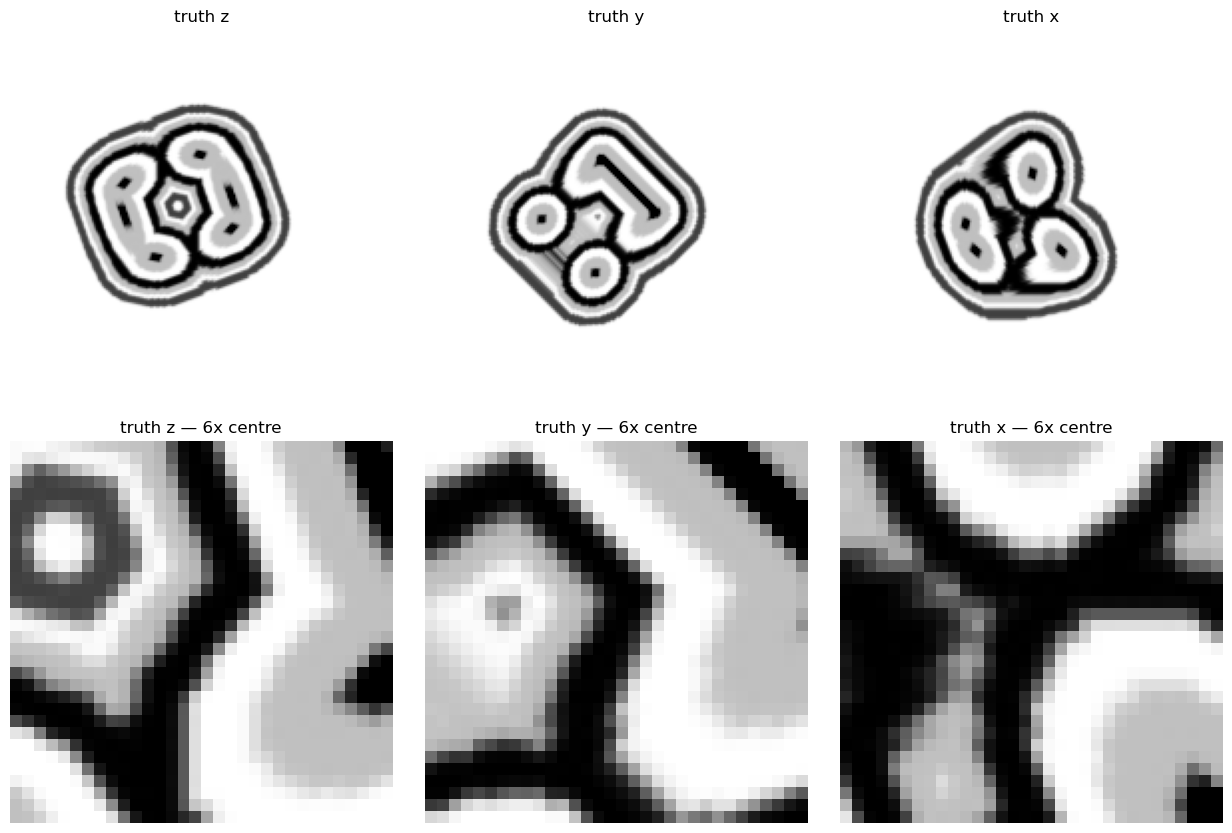

In [5]:
n, ntheta, ndist, niter = 128, 180, 4, 100
paganin = 100.0                   # delta/beta of the phantom, for the start
nobj = 3 * n // 2                 # room for the +-15 px displacement

obj = phantom3d(nobj)
prb = id16a_probe(n, ndist)
z1  = np.array([5.110, 5.464, 6.879, 9.817])[:ndist] * 1e-3
rng = np.random.default_rng(10)
pos     = (30 * (rng.random((ntheta, ndist, 2)) - 0.5)).astype('float32')
pos_err = (rng.random((ntheta, ndist, 2)) - 0.5).astype('float32')
theta   = np.linspace(0, np.pi, ntheta, dtype='float32')
print(f'object {obj.shape}, probe {prb.shape}')

slices('truth', obj, vref=obj[nobj // 2].real)

## Forward: four distances, 180 angles

2026-10-03 23:56:56 [rank=0] ndistchunk=4/4: 1 proj upload(s) per cascade sweep (was 4); GPU +8 MiB (pool 0.04->0.05 GiB, prb staging 0->2 MiB); host RAM unchanged
2026-10-03 23:56:56 [rank=0] tomo geometry: obj [192, 192, 192] -> proj [180, 192, 192]  (tomo_upsample=1, voxel aspect z:x = 1:1)


/home/beams2/VNIKITIN/holotomocupy_gpu_reduced/src/holotomocupy/conv2d_cufftdx.py:265: UserWarning: nvcc not found (NVCC='nvcc'). Set NVCC env var or add nvcc to PATH. Falling back to cuPy FFT.
  if cufftdx_available():


2026-10-03 23:56:56 [rank=0] iter=-1: shrink A*t+B  d0: y=(A=+0.0000e+00 B=+0.0000e+00)  x=(A=+0.0000e+00 B=+0.0000e+00)  d1: y=(A=+0.0000e+00 B=+0.0000e+00)  x=(A=+0.0000e+00 B=+0.0000e+00)  d2: y=(A=+0.0000e+00 B=+0.0000e+00)  x=(A=+0.0000e+00 B=+0.0000e+00)  d3: y=(A=+0.0000e+00 B=+0.0000e+00)  x=(A=+0.0000e+00 B=+0.0000e+00)


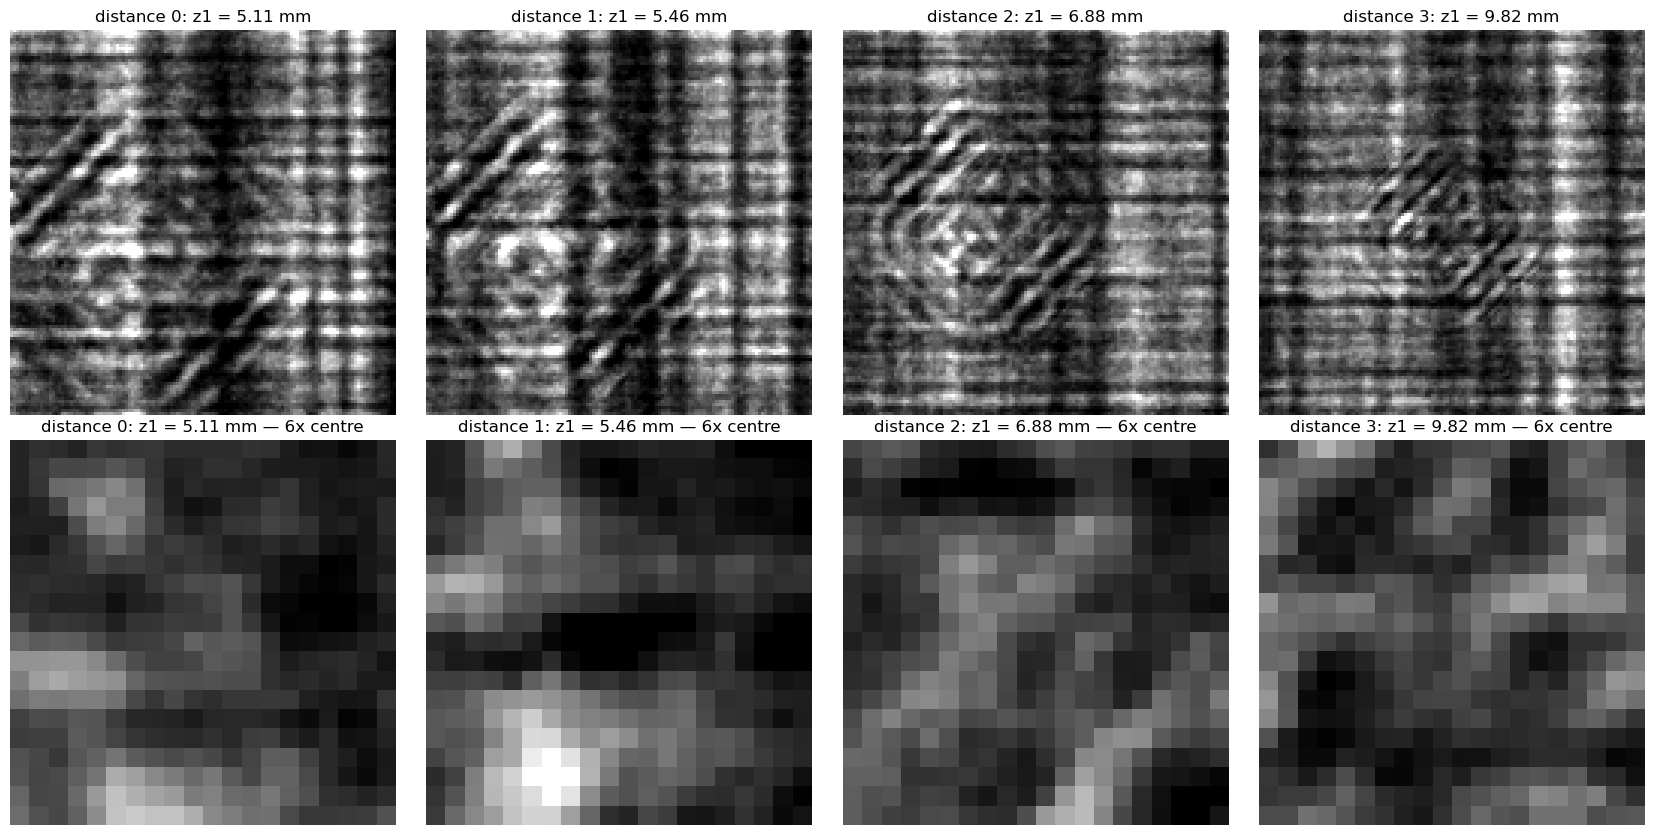

In [ ]:
from holotomocupy.rec_mpi import Rec
from holotomocupy.writer import Writer

args = SimpleNamespace(
    energy=17.1, detector_pixelsize=1.4760147601476e-6 * 2 * 8,
    focustodetectordistance=1.217, z1=z1, theta=theta,
    ndist=ndist, ntheta=ntheta, nz=n, n=n, nzobj=nobj, nobj=nobj,
    mask=0.9, lam_prbfit=2e-3, lam_laplacian=0, rho=[1, 0.05, 0.02, 0],
    shift_type='cubic',
    niter=niter, nchunk=16, checkpoint_step=niter // 4,
    error_step=niter // 8, start_iter=0, comm=comm)
cl = Rec(args)
writer = Writer(path_out='./demo_out/rec', comm=comm, st_obj=cl.st_obj,
                end_obj=cl.end_obj, nzobj=nobj, nobj=nobj, st_theta=cl.st_theta,
                end_theta=cl.end_theta, ntheta=ntheta, ndist=ndist, nz=n, n=n)

cl.vars['obj'][:] = obj
cl.vars['prb'][:] = prb
cl.vars['pos'][:] = pos.transpose(1, 0, 2)
cl.gen_data(cl.vars, cl.data)
cl.cl_prb_term.gen_sqrt_ref(cl.vars['prb'], cl.ref)   # the synthetic flat

panels([(f'distance {k}: z1 = {z1[k] * 1e3:.2f} mm', cp.asnumpy(cl.data[k, 0]))
        for k in range(ndist)])

## Step 5's starting point: multi-distance Paganin + FBP

Three things, and all three are needed:

* **divide by the reference.** Paganin wants the *flat-field normalised*
  intensity. Feeding it the raw frames leaves the probe's own structure in
  `log(data)` and the result is nonsense — correlation with the truth 0.34
  instead of 0.90.
* **resample each plane onto the object grid**, since the four distances are
  differently demagnified.
* then one multi-distance inversion per angle, and one FBP.

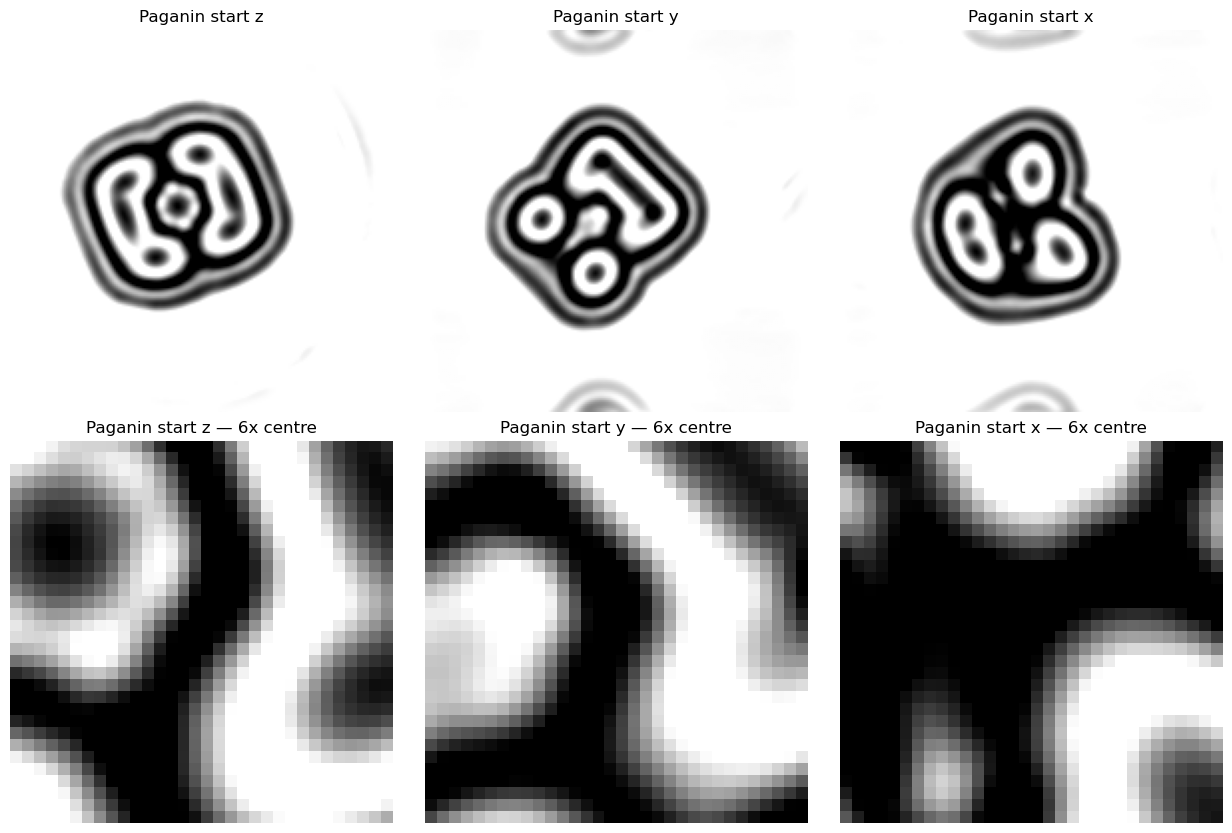

In [7]:
def multi_paganin(data, distances, wavelength, voxelsize, delta_beta, alpha=1e-2):
    """Phase from [ndist, ny, nx] flat-field-normalised intensities."""
    fx = cp.fft.fftfreq(data.shape[-1], d=voxelsize).astype('float32')
    fy = cp.fft.fftfreq(data.shape[-2], d=voxelsize).astype('float32')
    fx, fy = cp.meshgrid(fx, fy)
    num = den = 0
    for j in range(data.shape[0]):
        taylor = 1 + wavelength * distances[j] * cp.pi * delta_beta * (fx**2 + fy**2)
        num += taylor * cp.fft.fft2(data[j].astype('complex64'))
        den += taylor**2
    num /= len(distances)
    den = den / len(distances) + alpha
    return cp.log(cp.real(cp.fft.ifft2(num / den))) * delta_beta * 0.5


mags = cp.asarray(1.0 / cl.norm_magnifications, dtype='float32')
ref = cp.asarray(cl.ref) ** 2                     # cl.ref is an AMPLITUDE
psi = cp.zeros((ntheta, nobj, nobj), dtype='complex64')
for i in range(ntheta):
    big = cp.empty((ndist, nobj, nobj), dtype='float32')
    for k in range(ndist):
        r = cp.asarray(cl.vars['pos'][k][i:i + 1])
        m = cp.broadcast_to(mags[k], (1, 2)).copy()
        rdata = cp.asarray(cl.data[k, i:i + 1]) / (ref[k] + 1e-5)
        big[k] = cp.exp(cl.cl_shift.curlySback(
            cp.log(rdata.astype('complex64')), r, m)[0].real)
    ph = multi_paganin(big, cl.cl_prop.distance, cl.cl_prop.wavelength,
                       cl.cl_prop.voxelsize, paganin)
    psi[i] = ph + 1j * ph / paganin

obj0 = cp.empty((nobj, nobj, nobj), dtype='complex64')
for z in range(0, nobj, cl.nchunk):          # cl_tomo is sized for nchunk slices
    z1_ = min(z + cl.nchunk, nobj)
    obj0[z:z1_] = cl.cl_tomo.fbp(cp.ascontiguousarray(psi[:, z:z1_]), 'ramp')
obj0 = cp.asnumpy(obj0)

slices('Paganin start', obj0, vref=obj[nobj // 2].real)

## Inverse

That volume, a flat probe, and positions off by ~0.5 px.

In [ ]:
cl.vars['obj'][:] = obj0
cl.vars['prb'][:] = 1
cl.vars['pos'][:] = (pos + pos_err).transpose(1, 0, 2)
cl.BH(writer=writer)

2026-10-03 23:57:32 [rank=0] data mask dist 0: eff_demag<=(y 1.00000, x 1.00000) |pos|<=15.21px margin=2px -> per-angle keeps 100.0% of the pixels (min 100.0%, max 100.0%; one shared centred box would keep 100.0%)
2026-10-03 23:57:32 [rank=0] data mask dist 1: eff_demag<=(y 1.06928, x 1.06928) |pos|<=15.09px margin=2px -> per-angle keeps 100.0% of the pixels (min 100.0%, max 100.0%; one shared centred box would keep 100.0%)
2026-10-03 23:57:32 [rank=0] data mask dist 2: eff_demag<=(y 1.34618, x 1.34618) |pos|<=15.40px margin=2px -> per-angle keeps 97.3% of the pixels (min 90.1%, max 100.0%; one shared centred box would keep 79.3%)
2026-10-03 23:57:32 [rank=0] data mask dist 3: eff_demag<=(y 1.92113, x 1.92113) |pos|<=15.37px margin=2px -> per-angle keeps 56.6% of the pixels (min 56.2%, max 57.4%; one shared centred box would keep 39.1%)
2026-10-03 23:57:32 [rank=0] data mask: keeps 88.5% of the data. F0 still divides by the FULL ntheta*ndist*nz*n, so reported errors scale with that fra

In [ ]:
rec = np.asarray(cl.vars['obj'])

# the honest numbers: distance to the truth, inside the solver's own mask.
# The `pos abs error` logged during BH is measured from the STARTING guess,
# so it grows as the refinement moves the positions towards the truth.
yy, xx, _ = np.mgrid[0:nobj, 0:nobj, 0:nobj] - (nobj - 1) / 2
m = (yy**2 + xx**2) < (0.9 * nobj / 2)**2
u, v = rec.real[m] - rec.real[m].mean(), obj.real[m] - obj.real[m].mean()
corr = (u * v).sum() / np.sqrt((u * u).sum() * (v * v).sum())
print(f'object correlation with the truth {corr:.4f}')
print(f'position error {np.abs(np.asarray(cl.vars["pos"]) - pos.transpose(1, 0, 2)).mean():.4f} px,'
      f' from {np.abs(pos_err).mean():.4f}')

In [ ]:
slices('reconstructed', rec, vref=obj[nobj // 2].real)

Checkpoints, mid-slice TIFFs, the position-error plot and `conv.csv` are in `demo_out/rec/`.